In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from xgboost import XGBRegressor

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [3]:
base_url = "https://data.cityofchicago.org/resource/85ca-t3if.csv"

params = {
    "$select": ",".join([
        "crash_date",
        "latitude",
        "longitude",
        "injuries_total",
        "crash_hour",
        "weather_condition",
        "lighting_condition",
        "first_crash_type",
        "trafficway_type",
        "posted_speed_limit",
        "prim_contributory_cause"
    ]),
    "$where": (
        "crash_date between '2023-01-01T00:00:00' and '2023-03-31T23:59:59' "
        "AND latitude IS NOT NULL AND longitude IS NOT NULL"
    ),
    "$limit": 200000
}

r = requests.get(base_url, params=params, timeout=120)
r.raise_for_status()

df = pd.read_csv(StringIO(r.text))
df.head()

,crash_date,latitude,longitude,injuries_total,crash_hour,weather_condition,lighting_condition,first_crash_type,trafficway_type,posted_speed_limit,prim_contributory_cause
0,2023-01-01T00:00:00.000,41.745661,-87.603955,0.0,0,UNKNOWN,UNKNOWN,PARKED MOTOR VEHICLE,ONE-WAY,30,UNABLE TO DETERMINE
1,2023-01-01T00:00:00.000,41.808098,-87.714291,0.0,0,RAIN,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,30,NOT APPLICABLE
2,2023-01-01T00:00:00.000,41.891263,-87.746667,0.0,0,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,30,UNABLE TO DETERMINE
3,2023-01-01T00:00:00.000,41.900082,-87.619415,0.0,0,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,DIVIDED - W/MEDIAN BARRIER,45,UNABLE TO DETERMINE
4,2023-01-01T00:01:00.000,41.880452,-87.656299,0.0,0,UNKNOWN,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,30,UNABLE TO DETERMINE


In [4]:
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")
df = df.dropna(subset=["crash_date", "latitude", "longitude"]).copy()

num_cols = ["latitude", "longitude", "injuries_total", "posted_speed_limit", "crash_hour"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

cat_cols = ["weather_condition", "lighting_condition", "first_crash_type",
            "trafficway_type", "prim_contributory_cause"]
for c in cat_cols:
    df[c] = df[c].fillna("UNKNOWN").astype(str)

df["date"] = df["crash_date"].dt.floor("D")
df["injury_flag"] = (df["injuries_total"].fillna(0) > 0).astype(int)

df.shape

(24878, 13)

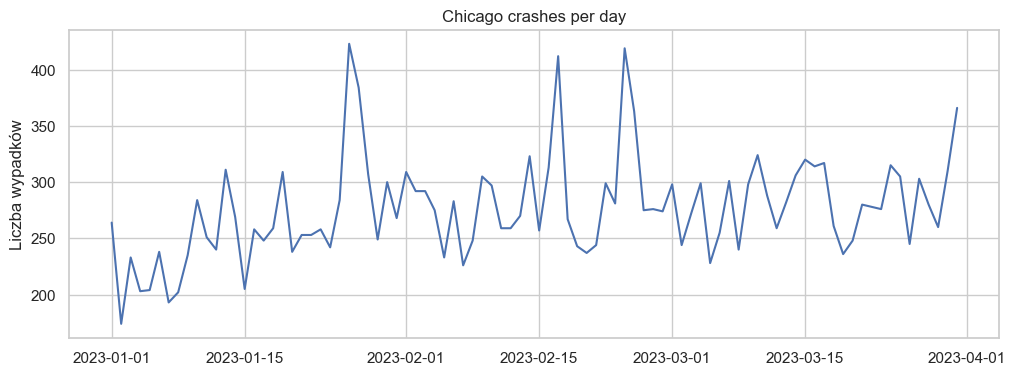

In [5]:
daily_counts = (
    df.groupby("date")
      .size()
      .rename("n_crashes")
      .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_counts, x="date", y="n_crashes")
plt.title("Chicago crashes per day")
plt.xlabel("")
plt.ylabel("Liczba wypadków")
plt.show()

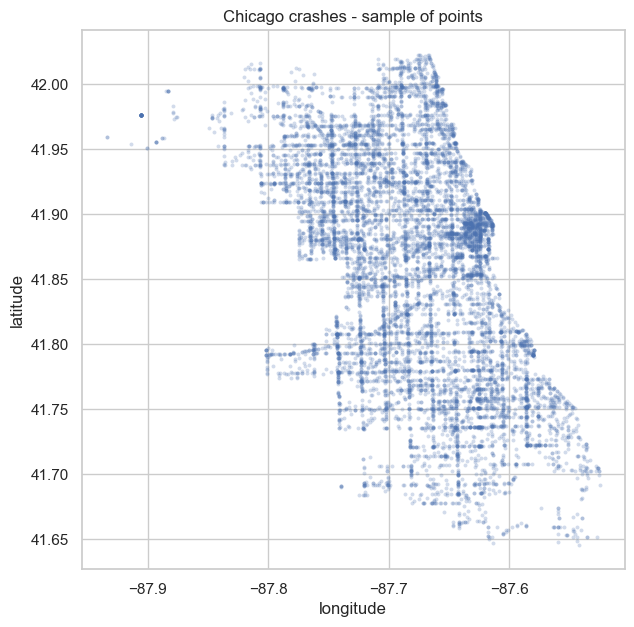

In [6]:
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="longitude",
    y="latitude",
    s=8,
    alpha=0.25,
    linewidth=0
)
plt.title("Chicago crashes - sample of points")
plt.show()

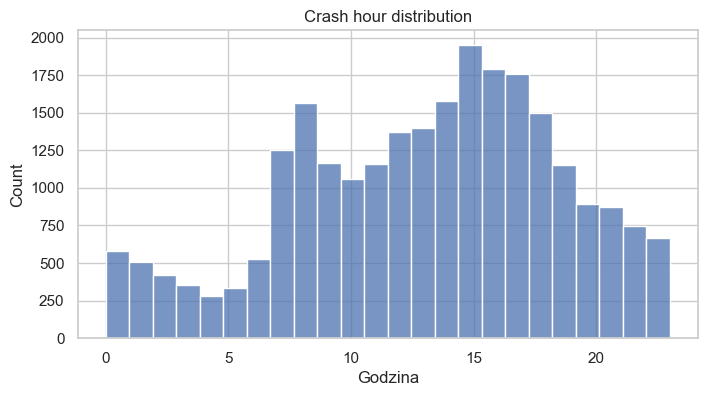

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df["crash_hour"].dropna(), bins=24)
plt.title("Crash hour distribution")
plt.xlabel("Godzina")
plt.show()

# Baseline: community areas + XGBoost
We build a simple baseline for daily crash counts by Community Area. We load boundaries, create a day x area panel, add basic time features, and train XGBoost.

In [8]:
community_url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"

areas = gpd.read_file(community_url)
areas.columns = [c.lower() for c in areas.columns]

if set(areas.columns) == {"geometry"}:
    geo = requests.get(community_url, timeout=60).json()
    areas = gpd.GeoDataFrame.from_features(geo["features"], crs="EPSG:4326")
    areas.columns = [c.lower() for c in areas.columns]

areas = areas.to_crs("EPSG:4326")

id_col_candidates = ["area_numbe", "area_number", "area_num", "area_num_1"]
name_col_candidates = ["community", "community_area", "community_name", "area_name", "comarea", "comarea_name", "name"]

id_col = next((c for c in id_col_candidates if c in areas.columns), None)
name_col = next((c for c in name_col_candidates if c in areas.columns), None)

if id_col is None or name_col is None:
    raise ValueError(f"Missing expected columns in community areas: {areas.columns}")

areas = areas.rename(columns={id_col: "community_area_id", name_col: "community_area"})
areas["community_area_id"] = pd.to_numeric(areas["community_area_id"], errors="coerce").astype("Int64")

areas = areas[["community_area_id", "community_area", "geometry"]].dropna(subset=["community_area_id"])
areas.head()

,community_area_id,community_area,geometry
0,1,ROGERS PARK,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,2,WEST RIDGE,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,3,UPTOWN,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,4,LINCOLN SQUARE,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,5,NORTH CENTER,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [9]:
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

gdf = gpd.sjoin(gdf, areas, how="left", predicate="within")

gdf[["community_area_id", "community_area"]].head()

,community_area_id,community_area
0,44,CHATHAM
1,57,ARCHER HEIGHTS
2,25,AUSTIN
3,8,NEAR NORTH SIDE
4,28,NEAR WEST SIDE


In [10]:
daily_area = (
    gdf.groupby(["date", "community_area_id", "community_area"])
       .size()
       .rename("n_crashes")
       .reset_index()
)

all_dates = pd.date_range(daily_area["date"].min(), daily_area["date"].max(), freq="D")
all_areas = areas[["community_area_id", "community_area"]].drop_duplicates()

grid = pd.MultiIndex.from_product(
    [all_dates, all_areas["community_area_id"]],
    names=["date", "community_area_id"],
).to_frame(index=False)
grid = grid.merge(all_areas, on="community_area_id", how="left")

daily_area = grid.merge(
    daily_area,
    on=["date", "community_area_id", "community_area"],
    how="left",
)
daily_area["n_crashes"] = daily_area["n_crashes"].fillna(0).astype(int)

daily_area.head()

,date,community_area_id,community_area,n_crashes
0,2023-01-01,1,ROGERS PARK,6
1,2023-01-01,2,WEST RIDGE,4
2,2023-01-01,3,UPTOWN,3
3,2023-01-01,4,LINCOLN SQUARE,2
4,2023-01-01,5,NORTH CENTER,1


In [11]:
daily_area = daily_area.sort_values(["community_area_id", "date"]).reset_index(drop=True)

daily_area["dow"] = daily_area["date"].dt.dayofweek
daily_area["month"] = daily_area["date"].dt.month
daily_area["weekofyear"] = daily_area["date"].dt.isocalendar().week.astype(int)
daily_area["is_weekend"] = (daily_area["dow"] >= 5).astype(int)

daily_area["dow_sin"] = np.sin(2 * np.pi * daily_area["dow"] / 7)
daily_area["dow_cos"] = np.cos(2 * np.pi * daily_area["dow"] / 7)

for lag in [1, 7, 14]:
    daily_area[f"lag_{lag}"] = (
        daily_area.groupby("community_area_id")["n_crashes"].shift(lag)
)

daily_area["rolling_7"] = (
    daily_area.groupby("community_area_id")["n_crashes"]
              .shift(1)
              .rolling(7)
              .mean()
              .reset_index(level=0, drop=True)
)

lag_cols = ["lag_1", "lag_7", "lag_14", "rolling_7"]
daily_area[lag_cols] = daily_area[lag_cols].fillna(0)

daily_area.head()

,date,community_area_id,community_area,n_crashes,dow,month,weekofyear,is_weekend,dow_sin,dow_cos,lag_1,lag_7,lag_14,rolling_7
0,2023-01-01,1,ROGERS PARK,6,6,1,52,1,-0.781831,0.623490,0.0,0.0,0.0,0.0
1,2023-01-02,1,ROGERS PARK,1,0,1,1,0,0.000000,1.000000,6.0,0.0,0.0,0.0
2,2023-01-03,1,ROGERS PARK,3,1,1,1,0,0.781831,0.623490,1.0,0.0,0.0,0.0
3,2023-01-04,1,ROGERS PARK,3,2,1,1,0,0.974928,-0.222521,3.0,0.0,0.0,0.0
4,2023-01-05,1,ROGERS PARK,8,3,1,1,0,0.433884,-0.900969,3.0,0.0,0.0,0.0


In [12]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "community_area_id",
    "dow",
    "month",
    "weekofyear",
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
]

X = daily_area[feature_cols].copy()
y = daily_area["n_crashes"]

X = pd.get_dummies(X, columns=["community_area_id"], drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

xgb_model = XGBRegressor(
    objective="count:poisson",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

mae, rmse

(1.5747716426849365, np.float64(2.1143608790553903))

In [13]:
from sklearn.model_selection import TimeSeriesSplit, GroupShuffleSplit

def make_spatiotemporal_folds(data, n_time_splits=4, test_area_frac=0.2, random_state=42):
    dates = np.sort(data["date"].unique())
    tscv = TimeSeriesSplit(n_splits=n_time_splits)
    folds = []

    for fold_idx, (train_date_idx, test_date_idx) in enumerate(tscv.split(dates), start=1):
        train_dates = dates[train_date_idx]
        test_dates = dates[test_date_idx]

        train_time_mask = data["date"].isin(train_dates)
        test_time_mask = data["date"].isin(test_dates)

        train_subset = data.loc[train_time_mask]
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=test_area_frac,
            random_state=random_state + fold_idx,
        )
        _, test_area_idx = next(
            gss.split(train_subset, groups=train_subset["community_area_id"])
)
        test_area_ids = train_subset.iloc[test_area_idx]["community_area_id"].unique()

        train_area_mask = ~data["community_area_id"].isin(test_area_ids)
        test_area_mask = data["community_area_id"].isin(test_area_ids)

        train_mask = train_time_mask & train_area_mask
        test_mask = test_time_mask & test_area_mask

        folds.append((data.index[train_mask], data.index[test_mask]))
    return folds

spatiotemporal_folds = make_spatiotemporal_folds(daily_area)

cv_metrics = []
for fold_id, (train_idx, test_idx) in enumerate(spatiotemporal_folds, start=1):
    X_train_cv = X.loc[train_idx]
    y_train_cv = y.loc[train_idx]
    X_test_cv = X.loc[test_idx]
    y_test_cv = y.loc[test_idx]

    model_cv = XGBRegressor(
        objective="count:poisson",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model_cv.fit(X_train_cv, y_train_cv)
    preds_cv = model_cv.predict(X_test_cv)

    fold_mae = mean_absolute_error(y_test_cv, preds_cv)
    fold_rmse = root_mean_squared_error(y_test_cv, preds_cv)
    cv_metrics.append({"fold": fold_id, "mae": fold_mae, "rmse": fold_rmse})

pd.DataFrame(cv_metrics)

,fold,mae,rmse
0,1,1.796976,2.354772
1,2,1.683125,2.220489
2,3,1.952886,2.768939
3,4,1.650580,2.200405


# Label definition
We predict next-day crashes for area $s$:
$$

y_{s,t+1} = \text{number of crashes in area } s \text{ on day } t+1
$$

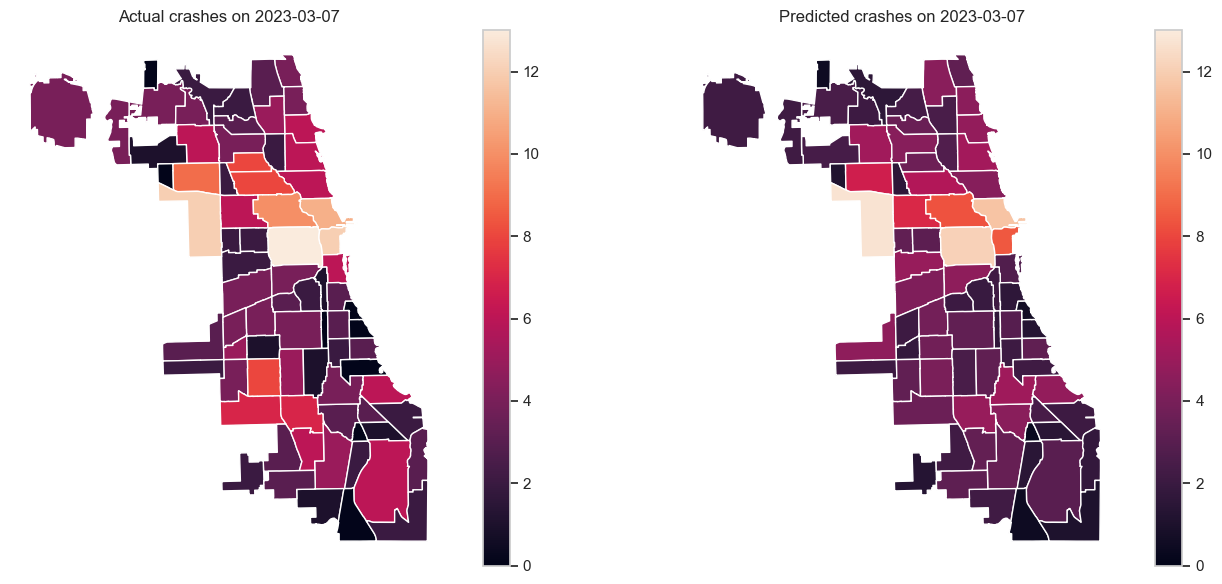

In [ ]:
idx = np.arange(len(daily_area))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
)
test_subset = daily_area.iloc[test_idx].copy()

sample_date = test_subset["date"].value_counts().idxmax()
day_data = daily_area[daily_area["date"] == sample_date].copy()

X_day = day_data[feature_cols].copy()
X_day = pd.get_dummies(X_day, columns=["community_area_id"], drop_first=False)
X_day = X_day.reindex(columns=X.columns, fill_value=0)

day_data["predicted"] = xgb_model.predict(X_day)

map_df = areas.merge(day_data, on="community_area_id", how="left")
vmax = max(map_df["n_crashes"].max(), map_df["predicted"].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
map_df.plot(
    column="n_crashes",
    ax=axes[0],
    legend=True,
    vmin=0,
    vmax=vmax,
    missing_kwds={"color": "lightgrey", "label": "no data"},
)
axes[0].set_title(f"Actual crashes on {sample_date.date()}")
axes[0].set_axis_off()

map_df.plot(
    column="predicted",
    ax=axes[1],
    legend=True,
    vmin=0,
    vmax=vmax,
    missing_kwds={"color": "lightgrey", "label": "no data"},
)
axes[1].set_title(f"Predicted crashes on {sample_date.date()}")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()